# Interpolation in higher dimensions

In [1]:
# initialization
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

As it turns out, the concept of linear interpolation can be extended to $n > 1$ dimensions. However, the proper generalization differs depending on whether data exists on a regular (or rectangular) grid or not. Consequently, there is a different interface for each case.

## Intepolation on regular grid

Let's look at our sea surface temperature data again, this time as a function of both latitude and longitude

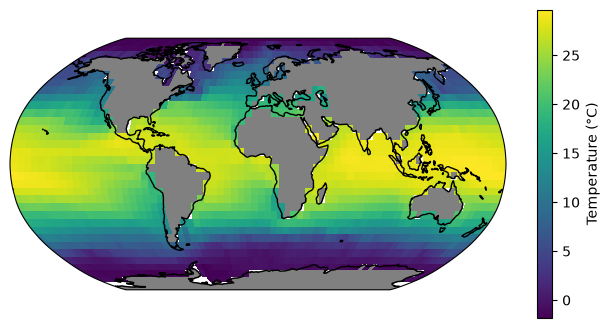

In [2]:
woa23 = xr.open_dataset("data/woa23_decav_t00_5d.nc", decode_times=False)
sst = woa23["t_mn"].sel(depth=0, method="nearest").squeeze()
sst_lat = sst.coords["lat"].values
sst_lon = sst.coords["lon"].values
sst_val = sst.values

fig = plt.figure(figsize=(8, 4))
ax = fig.add_subplot(projection=ccrs.Robinson())

im = ax.pcolormesh(sst_lon, sst_lat, sst_val, transform=ccrs.PlateCarree())
cb = fig.colorbar(im)

cb.set_label("Temperature (°C)")

ax.add_feature(cfeature.LAND, color="gray")
ax.coastlines()

plt.show(fig)

Let's focus on a patch of the ocean near the Axial Seamount (approx. 46°N, 130°W)

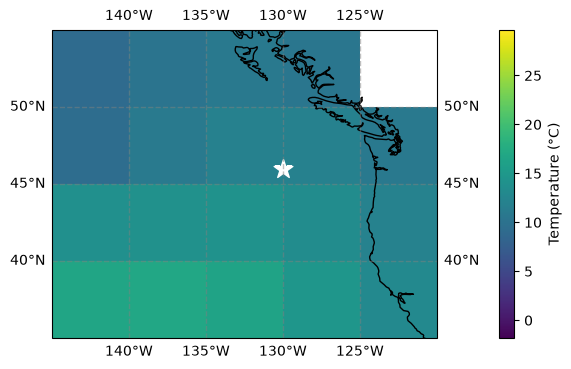

In [3]:
fig = plt.figure(figsize=(8, 4))
ax = fig.add_subplot(projection=ccrs.PlateCarree())

ax.set_extent([-145, -120, 35, 55], crs=ccrs.PlateCarree())

ax.coastlines()

im = ax.pcolormesh(sst_lon, sst_lat, sst_val, transform=ccrs.PlateCarree())
cb = fig.colorbar(im, pad=0.1)

ax.scatter(-130, 46, marker="*", color="white", s=200)

cb.set_label("Temperature (°C)")

gl = ax.gridlines(
    crs=ccrs.PlateCarree(), draw_labels=True, 
    linewidth=1, color='gray', alpha=0.5, linestyle='--'
)
gl.xlocator = mticker.FixedLocator(np.arange(-145, 120, 5))
gl.ylocator = mticker.FixedLocator(np.arange(35, 55, 5))
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

plt.show(fig)

Notice that we have data on a regular grid. Now let's use linear interpolation to assign a sea surface temperature at the location of the seamount. The function we need is `RegularGridInterpolator` from the `scipy.interpolate` submodule:

In [4]:
from scipy.interpolate import RegularGridInterpolator

The `RegularGridInterpolator` function takes two mandatory arguments. The first argument is a tuple of numpy arrays specifying the coordinates of the dimensions of the data, while the second argument is the values of the data at the specified coordinates. In our case, the data is two-dimensional, with rows (axis 0) corresponding to different latitudes and columns (axis 1) corresponding to different longitudes. Thus, the first argument should take the form (_latitudes_, _longitudes_). Hence, our code is:

In [5]:
reg_interp = RegularGridInterpolator((sst_lat, sst_lon), sst_val)

The output of `RegularGridInterpolator` is a function. To call this function, we supply a numpy array for which the last axis corresponds to the coordinates of a single point to evaluate the interpolator at. Thus, for the Axial Seamount, we supply:

In [6]:
reg_interp(np.array([46, -130]))

array([12.4276814])

in other words, the interpolated sea surface temperature at the seamount is 12.43°C

As before, it is possible to evaluate the interpolator at a collection of coordinates in one go. As an example, let's say we want to upsample the region shown in the above plot at 1° resolution, we first construct the input argument to `reg_interp` using a combination of `np.meshgrid` and `np.stack`:

In [7]:
new_lon = np.arange(-145, -119.9, 1)
new_lat = np.arange(35, 55.1, 1)

new_coords = np.stack(np.meshgrid(new_lat, new_lon, indexing='ij'), axis=-1)

In the above, `np.meshgrid` is used to create two two-dimensional arrays from `new_lon` and `new_lat`, and `np.stack` assemble them into a single 3-axes array. The `indexing` argument and the `axis` argument are set so that when `new_coords` is fed into `reg_interp` the output will have latitudes as rows and longitudes as columns.

All it remains is to feed `new_coords` into `reg_interp`:

In [8]:
new_sst = reg_interp(new_coords)

Visualizing the results:

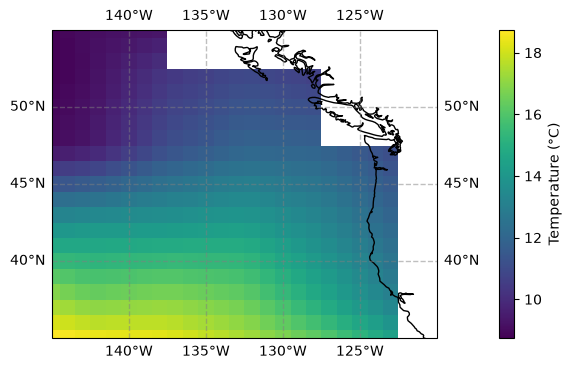

In [9]:
fig = plt.figure(figsize=(8, 4))
ax = fig.add_subplot(projection=ccrs.PlateCarree())

ax.set_extent([-145, -120, 35, 55], crs=ccrs.PlateCarree())

ax.coastlines()

im = ax.pcolormesh(new_lon, new_lat, new_sst, transform=ccrs.PlateCarree())
cb = fig.colorbar(im, pad=0.1)

cb.set_label("Temperature (°C)")

gl = ax.gridlines(
    crs=ccrs.PlateCarree(), draw_labels=True, 
    linewidth=1, color='gray', alpha=0.5, linestyle='--'
)
gl.xlocator = mticker.FixedLocator(np.arange(-145, 120, 5))
gl.ylocator = mticker.FixedLocator(np.arange(35, 55, 5))
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

plt.show(fig)

## Intepolation on unstructured data